In [1]:
import CMGDB
import RoA

import numpy as np  
import matplotlib.pyplot as plt  # module to plot graphs
import graphviz  # module to plot digraphs

import CMGDB_util
import sys

from datetime import datetime

MG_util = CMGDB_util.CMGDB_util()

First define a function $f:\mathbb{R} \rightarrow \mathbb{R}$

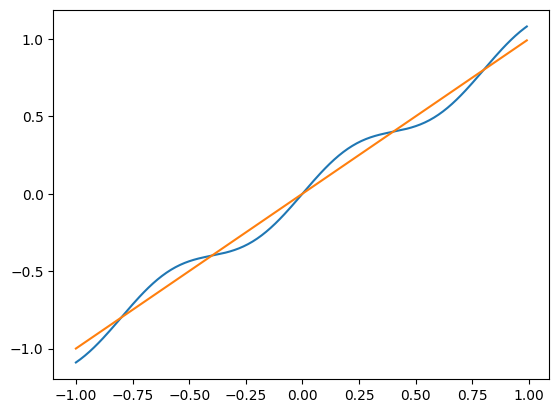

In [2]:
# parameters for the small perturbation to the function
a = 0.09
b = 2.5*np.pi

def f(x):
    return x + a*np.sin(b*x)

# plot function
x = np.arange(-1, 1, 0.01)   # start,stop,step
y = f(x)
plt.plot(x,y)

y = x
plt.plot(x,y)
plt.show()

In [3]:
# Define g = [f, ..., f] where g: [-1,1]^(len(X)) to [-1,1]^(len(X))

def g(X):
    # compute the images based on f
    Y = [f(x) for x in X]
    # add some relations between output to make the map more interesting 
    Y[1] *= Y[0]
#     Y[0] *= Y[1]
    # bring back to [-1,1] (torus)
    Y = [(y+1) % 2 -1 for y in Y]
    return Y

g([-1,-1])

[0.9099999999999999, -0.8118999999999996]

In [4]:
-1.09%2 -1

-0.09000000000000008

In [5]:
# auxilary function to plot the trajectories
def iterate(f, initial, n = 10):
    traj = [initial]
    y = f(initial)
    for i in range(n):
        traj += [y]
        y = f(y)
    return np.array(traj)

[[1, 1], [-1, 0.6], [0.7, 0], [-0.85, 0], [-0.1, -0.1], [0, 1], [0, 0.8]]


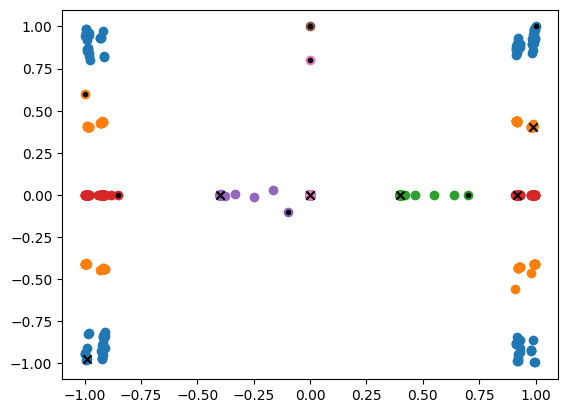

In [6]:
# select initial points to plot trajectories
initials = [[1,1], [-1,0.6], [0.7,0], [-0.85,0], [-0.1,-0.1], [0,1], [0, 0.8]]

print(initials)

for initial in initials:
    # iterate the function and create a plot
    traj = iterate(g, initial, n = 100)

    plt.scatter(traj[:,0],traj[:,1])
    plt.scatter(traj[0,0],traj[0,1], marker='.', c='k') # start at black dot
    plt.scatter(traj[-1,0],traj[-1,1], marker='x', c='k') # end at black "x"


plt.show()

torus
0:00:02.492313


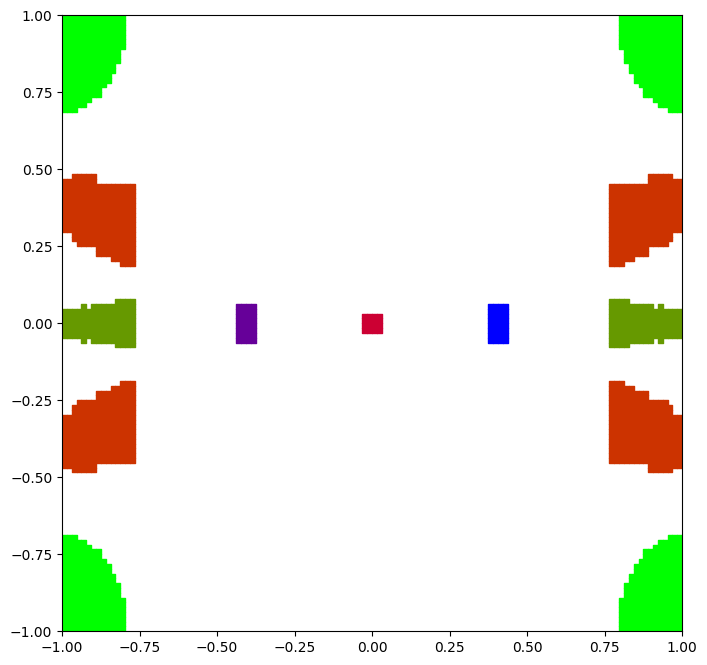

Time to build the regions of attraction = 0:00:01.908189
dictionary with volume of all Morse tiles = {0: 1.48291015625, 3: 0.49609375, 1: 1.48291015625, 2: 0.12109375}


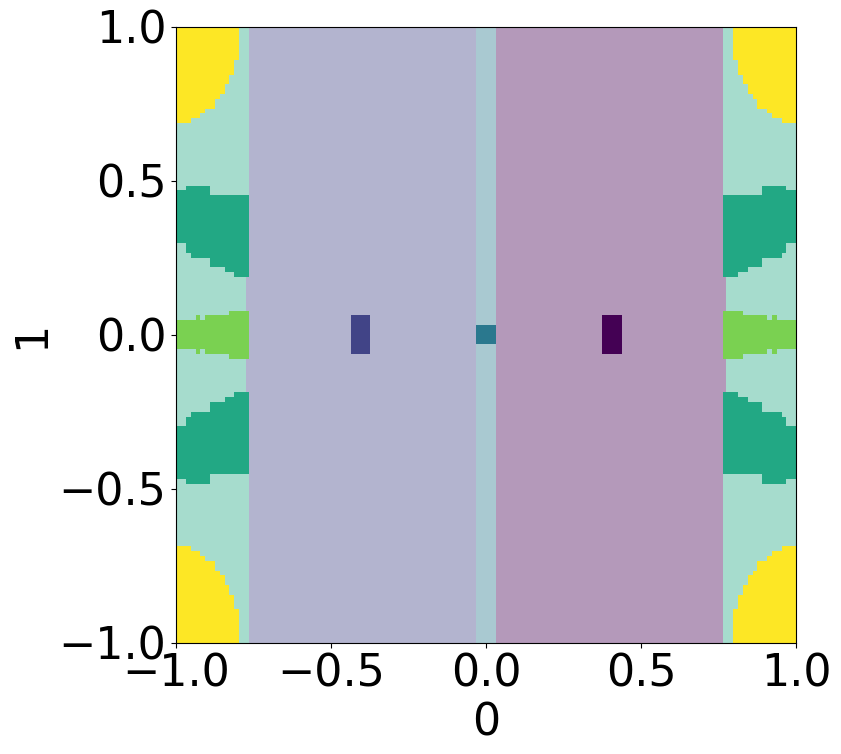

In [7]:
sb = 14

# subdiv_min = 10  # minimal subdivision to compute Morse Graph
# subdiv_max = 10  # maximal subdivision to compute Morse Graph
subdiv_init = subdiv_min = subdiv_max = sb  # non adaptive proceedure

subdiv_init = 14
subdiv_min = 14
subdiv_max = 16


x_min = -1
x_max = 1

y_min = -1
y_max = 1


# base name for the output files.
base_name = "torus"


print(base_name)


# Define the parameters for CMGDB
lower_bounds = [x_min, y_min]
upper_bounds = [x_max, y_max]



phase_periodic = [True, True]

K = [2, 2]

def F(rect):
#     return MG_util.BoxMapK(g, rect, K)
    return CMGDB.BoxMap(g, rect, padding=True)


morse_graph, map_graph = MG_util.run_CMGDB(
    subdiv_min, subdiv_max, lower_bounds, upper_bounds, phase_periodic, F, base_name, subdiv_init)

CMGDB.PlotMorseSets(morse_graph)

startTime = datetime.now()

roa = RoA.RoA(map_graph, morse_graph)

print(f"Time to build the regions of attraction = {datetime.now() - startTime}")

roa.save_file(base_name)

fig, ax = roa.PlotTiles()

# RoA.PlotTiles(lower_bounds, upper_bounds,
#               from_file=base_name, from_file_basic=True)

plt.show()

# roa.save_file(base_name)


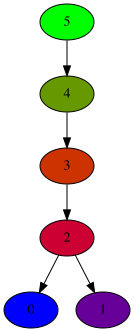

In [8]:
CMGDB.PlotMorseGraph(morse_graph)